## Calculating the energy consumption of the English Housing Stock using CUBES with data from Tabula and Hotmaps

### Importing modules

In [1]:
from cubes.construct import building
from cubes.construct import sample
from cubes.construct.extractor import Extractor
from cubes.construct import constants
from cubes.construct.building import Building
from cubes.package.simple_simulation import prepare_simulation
from cubes.package import envconfig
from geomeppy import IDF
import pandas as pd

import os
from pathlib import Path

### Defining methods

In [40]:
def test_specific_idf(building_code):
    geometry_data = constants.raw_geometry_data[constants.raw_geometry_data['REFERENCE BUILDING CODE'] == building_code]
    systems_data =constants.clean_system_data[constants.clean_system_data['Building typology'] == building_code]

    geometry_data = geometry_data.reset_index(drop = True)
    extracted = Extractor(geometry_data, systems_data)

    BC = extracted.create_building_config_object()
    EC = envconfig.EnvConfig(observe_zone_temperature=True,observe_electricity_demand=True,observe_outside_temperature=True)    
    building=Building(BC)
    building.build()
    idf = building.get_idf()

    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    output_directory_path = os.path.join(env_data_path, "output")

    Path(env_data_path).mkdir(parents=True, exist_ok=True)
    Path(output_directory_path).mkdir(parents=True, exist_ok=True)

    idf,weather_file=prepare_simulation(idf,BC,EC)
    
    idf.save(filename=env_data_path + "/test1.idf")
    print(weather_file)
    idf.run(
        expandobjects=True,
        readvars=True,
        weather=weather_file,
        output_directory=output_directory_path,
)


def run_archetypes(codes):
    data = {'Code': [], 'Energy / GJ': []}

    for code in codes:
        test_specific_idf(code)
        ht = pd.read_html("/workspaces/CUBES/exp/jack/EHS-energy-comparison/input_case_1/output/eplustbl.htm")[0]
        energy = ht.iloc[1,1]
        data['Code'].append(code)
        data['Energy / GJ'].append(energy)

    df = pd.DataFrame(data)

    return df

#### Getting the English Archetype codes

In [10]:
gb_ambience = pd.read_excel('/workspaces/CUBES/exp/jack/Data/UK_Data/GB_Ambience.xlsx')
num_buildings = gb_ambience['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']
gb_codes = gb_ambience.iloc[:,1]

### Running the simulations on the English Housing Stock
The annual energy consumption and code is stored within a dataframe, df

In [41]:
df = run_archetypes(gb_codes)

#### Adding information to the dataframe
Information like the number of buildings, total energy consumption and tabula's estimate

In [42]:
df = pd.concat([df, num_buildings], axis=1)
df['Energy'] = pd.to_numeric(df['Energy'])

In [88]:
tabula = {'Floor_Area / m2':[3362, 4357, 4045, 425, 481, 447, 559, 633, 693, 994, 994,
                             198, 153, 134, 123, 127, 141, 149, 149, 105, 93, 88, 85, 
                             74, 80, 98, 98], 
                             
        'Primary_Energy / kWh/m2' :[387.8, 307.9, 78.3, 423.5, 441.1, 437.8, 375.7, 
                                    318.7, 306.9, 89.8, 84.6, 228.3, 233.5, 231.7, 
                                    221.6, 194.6, 180.0, 97.6, 92.9, 238.5, 246.5, 
                                    238.6, 218.9, 205.9, 198.6, 99.4, 94.1]}

tabula_df = pd.DataFrame(tabula)

In [90]:
tabula_df['Total Energy / kWh'] = (tabula_df['Floor_Area / m2']*tabula_df['Primary_Energy / kWh/m2'])
tabula_df['num_buildings'] = df['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']
tabula_df['TABULA / TWh'] = (tabula_df['Total Energy / kWh']*tabula_df['num_buildings'])/10**9

In [92]:
df['CUBES / GJ'] = df['Energy / GJ']*df['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']
df['CUBES / TWh'] = (df['CUBES / GJ']*277.8)/10**9
df['TABULA / TWh'] = tabula_df['TABULA / TWh']
df['cumsum_Tabula'] = df['TABULA / TWh'].cumsum()
df['cumsum_CUBES'] = df['CUBES / TWh'].cumsum()


In [94]:
cwd_path = os.getcwd()
output_directory_path = os.path.join(cwd_path, "results")
df.to_csv('/workspaces/CUBES/exp/jack/EHS-energy-comparison/output/cubes_tabula_comparison.csv')
df.to_csv('/workspaces/CUBES/exp/jack/Data/cubes_tabula_comparison.csv')

#### Importing previously determined results

In [95]:
df = pd.read_csv('/workspaces/CUBES/exp/jack/Data/cubes_tabula_comparison.csv', index_col=0)

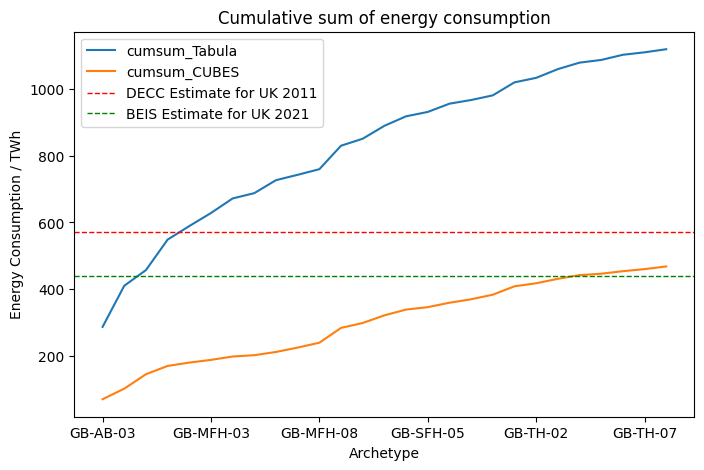

In [97]:
plot = df.plot.line(x='Code', y=['cumsum_Tabula', 'cumsum_CUBES'], figsize=(8,5))
plot.axhline(y=571, color= 'red', linewidth=1, linestyle='--', label="DECC Estimate for UK 2011")
plot.axhline(y=438, color= 'green', linewidth=1, linestyle='--', label="BEIS Estimate for UK 2021")
plot.set_title('Cumulative sum of energy consumption')

plot.set_ylabel('Energy Consumption / TWh')
plot.set_xlabel('Archetype')
plot.legend()



Text(0.5, 1.0, 'Comparison between CUBES and Tabula archetype energy consumption')

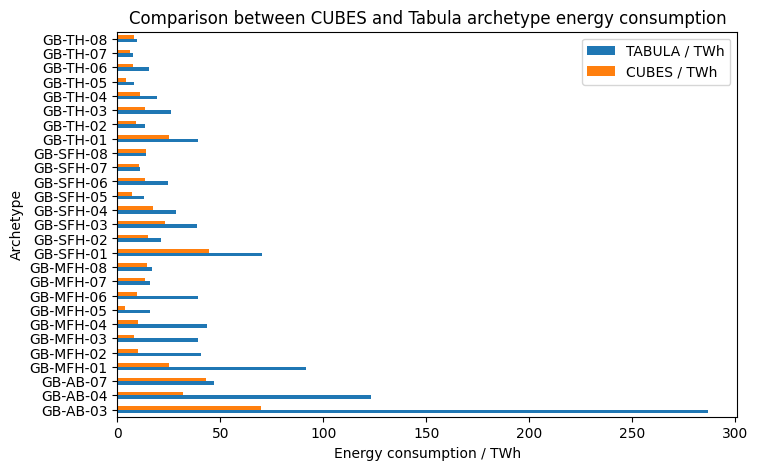

In [101]:
sp = df.plot.barh(x='Code', y=['TABULA / TWh', 'CUBES / TWh'], figsize=(8,5))
sp.set_xlabel('Energy consumption / TWh')
sp.set_ylabel('Archetype')
sp.set_title('Comparison between CUBES and Tabula archetype energy consumption')